# Dataset EDA, fairness checks, and classifier training

Companion to `ref material/BUILD.md` S5.3–S5.5. This notebook does three things, in
this order, and the order matters:

1. **Audit the dataset before training on it.** Balance, length, vocabulary
   overlap, and the flag ground truth.
2. **Test whether the dataset is fair** — that is, whether a classifier could
   score well for the wrong reason. The leakage check is the one that would
   invalidate every downstream number if it failed, so it runs before training.
3. **Fine-tune MiniLM-L6** and write the artefacts the evaluation reads.

**Nothing here is a result.** Results live in `eval/results/`, produced by
`eval/run_eval.py` on the held-out test split. This notebook is where the dataset
is interrogated and the model is built; reporting happens elsewhere, deliberately,
so a number can never come from the same pass that fitted it.

In [1]:
from __future__ import annotations

import json
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook lives in models/, so the repository root is one level up.
ROOT = Path.cwd().parent if Path.cwd().name == "models" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

SEED = 42
np.random.seed(SEED)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print(f"root: {ROOT}")

root: c:\Users\ameli\Documents\all ur code projects\bojji


---
## 1. Load the corpus and the generated emails

The emails are frozen and committed, so this notebook never regenerates them. If
`emails.jsonl` is absent, run `python scripts/generate_emails.py` first — that step
uses a paid API and is deliberately not on the reproduction path.

In [2]:
from triage.sop.index import build_index

index = build_index()
print(f"SOPs: {len(index.sops)} ({len(index.indexed)} indexed, {len(index.held_out)} held out)")

EMAILS = ROOT / "data" / "generated" / "emails.jsonl"
if not EMAILS.exists():
    raise SystemExit(
        f"{EMAILS.relative_to(ROOT)} not found.\n"
        "Run: python scripts/generate_emails.py"
    )

df = pd.DataFrame([json.loads(line) for line in EMAILS.read_text(encoding="utf-8").splitlines()])
df["n_chars"] = df["body"].str.len()
df["n_words"] = df["body"].str.split().str.len()

# Subject + body is what the model is trained on and what every check below
# measures, so it is built once here rather than reassembled per cell.
df["text"] = (df["subject"].fillna("") + "\n\n" + df["body"]).str.strip()
print(f"{len(df):,} emails, {df['label'].nunique()} classes")
df.head(3)

SOPs: 17 (14 indexed, 3 held out)
1,800 emails, 12 classes


,id,received_at,from,subject,body,label,scenario_id,source_sops,computation_requested,account_specific,plant_pii,season,persona_role,literacy,register,generator_model,n_chars,n_words
0,ACCT-NOA-001-000,2026-06-19T14:02:00+00:00,tan21@example.com,Clarification Needed on Income Tax Bill,"I'm reviewing my income tax bill, and there's ...",account_specific,ACCT-NOA-001,[SOP-ESC-001],False,True,{'nric': 'S0433218J'},noa,employee,standard,anxious,gpt-4o,332,61
1,ACCT-NOA-001-001,2026-07-08T15:37:00+00:00,kumar10@example.com,Clarification Needed on Tax Bill Charge,I'm confused about a specific figure in my tax...,account_specific,ACCT-NOA-001,[SOP-ESC-001],False,True,{'nric': 'T3890838Z'},noa,employee,standard,anxious,gpt-4o,369,70
2,ACCT-NOA-001-002,2026-06-13T09:22:00+00:00,kumar87@example.com,Clarification Needed for Item on Tax Bill,I hope you can assist me with an issue on my r...,account_specific,ACCT-NOA-001,[SOP-ESC-001],False,True,{'nric': 'T6542351G'},noa,employee,standard,anxious,gpt-4o,363,72


---
## 2. Class balance and splits

Balance first, because every later check assumes it: an imbalanced corpus makes
accuracy a misleading summary and starves a class of test examples.

The split assignment is loaded here rather than computed, because two later checks
need it — the per-split balance table below, and the cross-split near-duplicate
check in §5.

**Why three splits, and why grouped.** 50 / 20 / 30, seeded and committed.
Calibration is separate from test on purpose: temperature scaling is *fitted* on
calibration and *reported* on test, so a calibration number is never produced from
the data that fitted it. The split groups whole scenarios rather than individual
emails, so paraphrases of one situation cannot straddle the train/test boundary —
which is also why the shares land near, rather than exactly on, 50/20/30.


In [3]:
# The split is READ, never recomputed here.
#
# `scripts/make_splits.py` is the single definition, and it groups by scenario:
# every variant of one scenario lands in the same split, so paraphrases of a
# situation cannot straddle the train/test boundary and inflate the test score.
# A stratified-by-class split computed in this notebook would be a second,
# contradictory implementation -- the same failure mode the shared architecture
# in `triage.models.head` exists to avoid (§7).
#
# Grouping whole scenarios is why the shares land near, not exactly on, 50/20/30.

SPLITS = ROOT / "data" / "splits" / "splits.json"
if not SPLITS.exists():
    raise SystemExit(
        f"{SPLITS.relative_to(ROOT)} not found.\n"
        "Run: python scripts/make_splits.py"
    )

assignment = json.loads(SPLITS.read_text(encoding="utf-8"))["assignment"]
df["split"] = df["id"].astype(str).map(assignment)

missing = int(df["split"].isna().sum())
assert missing == 0, f"{missing} emails have no split assignment; re-run make_splits.py"

print(df["split"].value_counts().reindex(["train", "calibration", "test"]).to_string())
print(f"\nscenarios: {df['scenario_id'].nunique()}  (grouped, none spans a split)")


split
train          879
calibration    401
test           520

scenarios: 113  (grouped, none spans a split)


label
account_specific            150
assessment_and_amendment    150
filing                      150
foreign_income_dta          150
hardship_or_waiver          150
oos_business_tax            150
oos_other_agency            150
payment                     150
rental_income               150
residency                   150
scam_report                 150
tax_reliefs                 150

min 150  max 150  spread 0


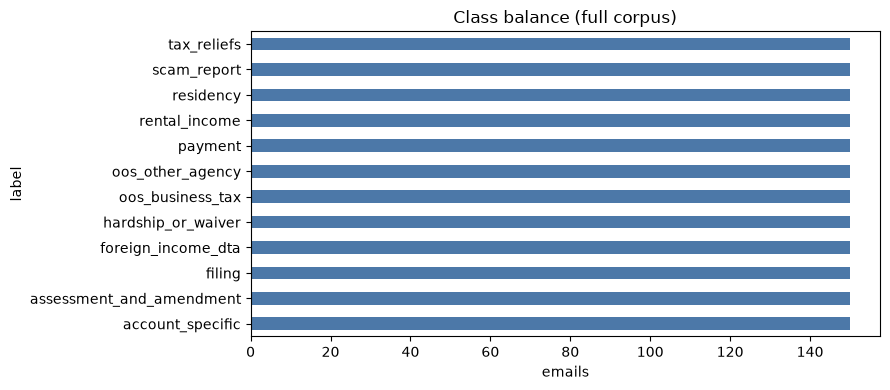

In [4]:
counts = df["label"].value_counts().sort_index()
print(counts.to_string())
print(f"\nmin {counts.min()}  max {counts.max()}  spread {counts.max() - counts.min()}")
assert counts.max() - counts.min() <= 1, "classes are not balanced"

fig, ax = plt.subplots(figsize=(9, 4))
counts.plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("emails"); ax.set_title("Class balance (full corpus)")
plt.tight_layout(); plt.show()

In [5]:
# Balance WITHIN each split. Grouping by scenario means the per-class test counts
# vary (36-49 on the committed split) rather than sitting exactly on 45: whole
# scenarios are indivisible. The floor guards the reportable minimum -- below ~30
# a per-class metric is too noisy to publish, which is the threshold
# scripts/make_splits.py warns at.
pivot = df.pivot_table(index="label", columns="split", values="id", aggfunc="count")
pivot = pivot[["train", "calibration", "test"]]
pivot["total"] = pivot.sum(axis=1)
display(pivot)

print(f"\ntest examples per class: min {pivot['test'].min()}, max {pivot['test'].max()}")
assert pivot["test"].min() >= 30, "a class is below the 30 test examples reporting needs"


split,train,calibration,test,total
label,,,,
account_specific,78,35,37,150
assessment_and_amendment,71,30,49,150
filing,75,27,48,150
foreign_income_dta,69,39,42,150
hardship_or_waiver,80,34,36,150
oos_business_tax,78,24,48,150
oos_other_agency,68,41,41,150
payment,74,32,44,150
rental_income,71,39,40,150



test examples per class: min 36, max 49


---
## 3. Length and style

Two questions:

- Is any class systematically longer or shorter? A length signal is a legitimate
  feature, but if it *alone* separated the classes the model could ignore the text.
- Did the style axis actually apply? Standard, imperfect and Singlish registers were
  requested; if the generator flattened them, the corpus is less varied than the
  writeup claims.

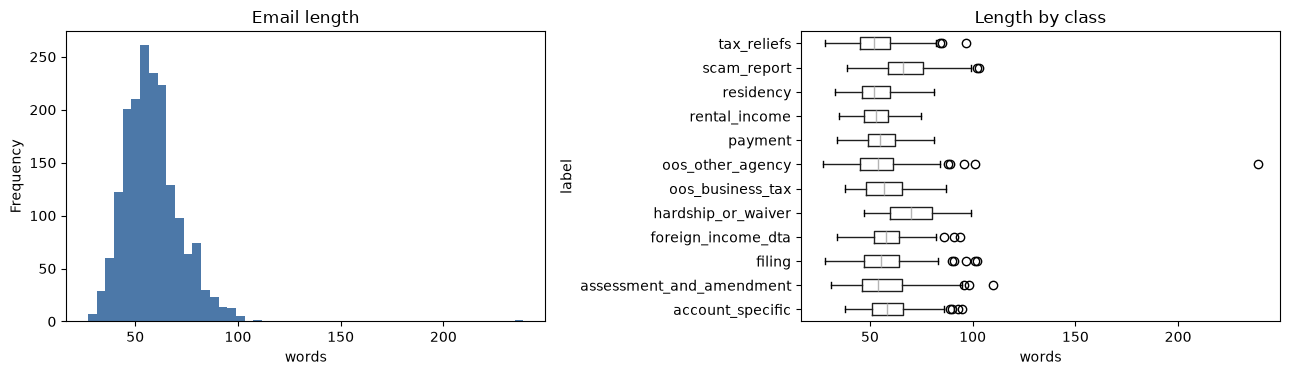

count    1800.000000
mean       58.217222
std        13.687330
min        27.000000
25%        49.000000
50%        57.000000
75%        66.000000
max       239.000000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["n_words"].plot.hist(bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_xlabel("words"); axes[0].set_title("Email length")

order = df.groupby("label")["n_words"].median().sort_values().index
df.boxplot(column="n_words", by="label", ax=axes[1], vert=False, grid=False)
axes[1].set_title("Length by class"); axes[1].set_xlabel("words")
plt.suptitle(""); plt.tight_layout(); plt.show()

print(df["n_words"].describe().to_string())

In [7]:
# Length must not be a giveaway on its own: if a one-feature model separates the
# classes well, the generator encoded the label in how much it wrote.
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Ceiling matches scripts/check_leakage.py LENGTH_CEILING, so the notebook
# and the gate that runs in CI cannot disagree about what "too predictive" is.
LENGTH_CEILING = 0.30

X_len = df[["n_words", "n_chars"]].to_numpy()
y = df["label"].to_numpy()

baseline = cross_val_score(DummyClassifier(strategy="most_frequent"), X_len, y, cv=5).mean()
length_only = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=SEED),
                              X_len, y, cv=5).mean()
print(f"majority-class baseline : {baseline:.3f}")
print(f"length-only classifier  : {length_only:.3f}  (chance = {1/df['label'].nunique():.3f})")
if length_only > LENGTH_CEILING:
    print("\nWARNING: length alone is unexpectedly predictive - inspect generation.")

majority-class baseline : 0.083
length-only classifier  : 0.118  (chance = 0.083)


In [ ]:
# The style axes were requested from the generator; this shows whether they
# actually landed. A flattened axis would mean the corpus is less varied than the
# writeup claims -- and a lopsided one would make a register a proxy for a class.
AXES = [a for a in ("literacy", "register", "season", "persona_role") if a in df.columns]

fig, axes = plt.subplots(1, len(AXES), figsize=(4 * len(AXES), 3.6))
for ax, axis in zip(np.atleast_1d(axes), AXES):
    share = df[axis].value_counts(normalize=True).sort_values() * 100
    ax.barh(share.index.astype(str), share.to_numpy(), color="#4C78A8")
    ax.set_title(axis, fontsize=10)
    ax.set_xlabel("% of corpus")
    for y_pos, value in enumerate(share.to_numpy()):
        ax.text(value + 0.5, y_pos, f"{value:.0f}%", va="center", fontsize=8)
    ax.set_xlim(0, max(share.max() * 1.18, 5))
plt.suptitle("Style axes: did the requested variation actually apply?", y=1.02)
plt.tight_layout(); plt.show()

# Cross-tabulated against the label: a register that predicts a class would be a
# confound, not a style.
for axis in AXES:
    share = df[axis].value_counts(normalize=True)
    spread = df.groupby(axis)["label"].nunique()
    print(f"{axis:14} {len(share)} values, "
          f"most common {share.idxmax()} at {share.max():.1%}, "
          f"each spanning {spread.min()}-{spread.max()} of {df['label'].nunique()} classes")


---
## 4. The fairness check that matters: vocabulary leakage

**This is the check that would invalidate everything downstream.**

The scenarios describe *situations*, never labels, precisely so the generator cannot
encode the answer in the wording. But intent is not proof. The test is empirical:
fit TF-IDF + logistic regression — a bag of words with no semantics at all — and see
how well it separates the classes.

Reading the result:

| Accuracy | Interpretation |
|---|---|
| ~0.08 | chance. The text carries no class signal — implausible for real language |
| 0.5–0.8 | **expected.** Words genuinely differ by topic; that is the task |
| >0.95 | **a problem.** A bag of words should not be near-perfect on natural email |

A very high score means a giveaway token exists, and the encoder would be learning
the generator's tell rather than the citizen's problem. The corpus would be rebuilt.

### What the committed corpus scored

| Check | Result | Reading |
|---|---|---|
| Balance | 150/class exactly | equal statistical power per topic |
| **Vocabulary (TF-IDF + logreg)** | **0.754** | in band: chance 0.083, ceiling 0.95 |
| System vocabulary | none found | no email reads as though it knows the taxonomy |
| Single-class confinement | 19 words, all topic nouns | no generator tell |
| Length-only classifier | 0.118 | ≈ chance (0.083) |
| Near-duplicates | 8 pairs > 0.9 | 0.4% of the corpus |
| Flag confounding | 6 classes each | not a proxy for the classifier |

### How to read 0.754

A bag of words with no semantics separates the classes three quarters of the time.
That is what an honest corpus looks like:

| Score | Meaning |
|---|---|
| ~0.08 | chance — the text carries no class signal, implausible for real language |
| **0.5–0.8** | **expected.** Topical words genuinely differ; that IS the task |
| > 0.95 | **a problem.** A giveaway token exists; rebuild the corpus |

"instalment" really does indicate a payment enquiry. A classifier is *supposed* to
use that. What would be fatal is near-perfect separation, which would mean the
generator left a tell — and the encoder would learn the tell rather than the
citizen's problem.

### A check that was wrong, and what replaced it

The first version failed 121 emails for containing "rental income", "tax relief" or
"foreign income", on the reasoning that these are class names.

That was a mistake. A landlord writing about a spare room says "rental income",
because that is the ordinary English name for the thing. The check was conflating
*the class is named after its topic* with *the generator leaked the label*.

Two pieces of evidence settled it:

1. None of those phrases appears anywhere in the scenario text the generator saw.
2. Words like "relief" and "overseas" bleed across class boundaries the way real
   vocabulary does — "relief" appears in relief, hardship and foreign-income emails
   alike — rather than sitting confined to one class.

It was replaced by two better checks: a list of **system vocabulary** a member of
the public would never write ("triage", "escalation bucket", "confidence score"),
and a **data-driven confinement scan** that finds candidate tells without needing a
hand-written list of them.


In [9]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline

# Measured over subject + body: the same text the model sees, and the same basis
# scripts/check_leakage.py uses. Body alone scores 0.739 rather than 0.754.
#
# cv=5 on a classifier is StratifiedKFold WITHOUT shuffling, so this is already
# deterministic -- rerunning gives the identical number, no seed required.
CHANCE = 1 / df["label"].nunique()
CEILING, FLOOR = 0.95, 0.30

leak = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=2000, random_state=SEED),
)
pred = cross_val_predict(leak, df["text"], y, cv=5)
acc = (pred == y).mean()

print(f"TF-IDF + logistic regression : {acc:.3f}")
print(f"chance                       : {CHANCE:.3f}")
print(f"failure ceiling              : {CEILING}")

if acc > CEILING:
    print("\n*** LEAKAGE — a giveaway token exists. Inspect features and rebuild. ***")
elif acc < FLOOR:
    print("\nUnusually low: the classes may be under-separated.")
else:
    print("\nIn the expected band: topical vocabulary differs, no giveaway.")


TF-IDF + logistic regression : 0.739
chance                       : 0.083
failure ceiling              : 0.95

In the expected band: topical vocabulary differs, no giveaway.


In [10]:
# What is the bag of words actually keying on? A token that IS the label - or a
# generator artefact - shows up here immediately.
leak.fit(df["text"], y)
vec, clf = leak.steps[0][1], leak.steps[1][1]
names = np.array(vec.get_feature_names_out())

for i, label in enumerate(clf.classes_):
    top = names[np.argsort(clf.coef_[i])[-8:]][::-1]
    print(f"{label:26} {', '.join(top)}")

account_specific           nric, my nric, nric is, is, my, why, been received, deduction
assessment_and_amendment   bill, tax bill, objection, amendment, believe, received, received tax, an
filing                     submit, tax return, to submit, return, deadline, year, submitted my, to file
foreign_income_dta         singapore, overseas, in singapore, here, abroad, work, in, here in
hardship_or_waiver         charge, payment, situation, options, was, pay, period, dont
oos_business_tax           business, small, partnership, small business, run small, run, keep, to keep
oos_other_agency           retirement account, my retirement, retirement, employer, my employer, register, to register, duty
payment                    payment, my account, instalment, day, instalments, refund, account, date
rental_income              rental, property, rental income, rent, renting, the rental, expenses, costs
residency                  singapore, in singapore, years, applied, year, status, in, taxed
sc

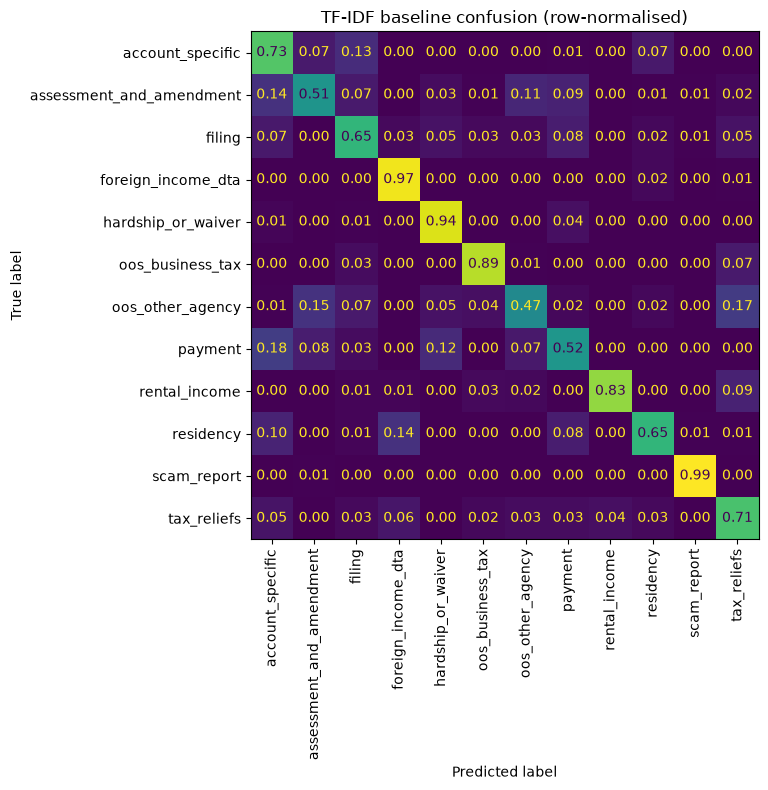

In [11]:
# The confusion matrix of the WEAK model is diagnostic: pairs it confuses are the
# genuinely hard ones, and should match the pairs the design predicted
# (account_specific vs its topic; the two out-of-scope classes; FIL vs ASM).
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y, pred, ax=ax, xticks_rotation=90, colorbar=False, normalize="true", values_format=".2f",
)
ax.set_title("TF-IDF baseline confusion (row-normalised)")
plt.tight_layout(); plt.show()

---
## 5. Near-duplicate check

Variants of one scenario are meant to differ. If the generator produced near-copies,
the effective dataset is smaller than 1,800 and — worse — near-duplicates split
across train and test would inflate the test score.

In [12]:
# TfidfVectorizer is already imported in the leakage cell above.
from sklearn.metrics.pairwise import cosine_similarity

# Similarity is measured over subject + body, matching both
# scripts/check_leakage.py (the gate that runs in CI) and the text the model is
# actually trained on in §7. Body alone finds 1 pair rather than 8, because two
# emails can share a near-identical subject line and still differ in the body --
# and the model sees that subject.
dup_texts = df["text"]

tfidf = TfidfVectorizer(min_df=1).fit_transform(dup_texts)
sim = cosine_similarity(tfidf)
np.fill_diagonal(sim, 0)

DUPLICATE_THRESHOLD = 0.90
pairs = np.argwhere(sim > DUPLICATE_THRESHOLD)
print(f"pairs with cosine > {DUPLICATE_THRESHOLD}: {len(pairs) // 2}")
print(f"max off-diagonal similarity: {sim.max():.3f}")
print(f"share of corpus involved: {len(np.unique(pairs)) / len(df):.1%}")

if len(pairs):
    i, j = pairs[0]
    print(f"\nclosest pair ({sim[i, j]:.3f}):")
    print(" A:", dup_texts.iloc[i][:150])
    print(" B:", dup_texts.iloc[j][:150])


pairs with cosine > 0.9: 8
max off-diagonal similarity: 0.948
share of corpus involved: 0.8%

closest pair (0.911):
 A: Missing Claim on Tax Bill

I noticed that a claim I am entitled to is missing from my recent tax bill. Could you please advise on how I can have this 
 B: Missing Claim on Tax Bill

I've reviewed my recent tax bill and noticed that a claim I am entitled to is missing. Could you please advise how I can ge


In [13]:
# Cross-split contamination is the version of this that actually corrupts a result.
# Grouping by scenario should make it impossible; this asserts it rather than
# assuming it.
tr = df.index[df["split"] == "train"].to_numpy()
te = df.index[df["split"] == "test"].to_numpy()
cross = sim[np.ix_(tr, te)]

print(f"max train-test similarity: {cross.max():.3f}")
print(f"test emails with a >0.9 twin in train: {(cross.max(axis=0) > 0.9).sum()}")
assert cross.max() < 0.95, "a near-duplicate spans the train/test boundary"


max train-test similarity: 0.527
test emails with a >0.9 twin in train: 0


---
## 6. Flag ground truth

`computation_requested` and `account_specific` are recorded by the scenario spec, so
their ground truth is free. Two things to confirm before they are used as metrics:

- **Enough positives to measure.** Precision and recall on a handful of examples are
  not reportable.
- **Not confounded with class.** If every computation-demanding email were
  `tax_reliefs`, the flag's measured performance would really be the classifier's.

In [14]:
for flag in ("computation_requested", "account_specific"):
    if flag not in df.columns:
        continue
    n = int(df[flag].sum())
    print(f"\n{flag}: {n} positives ({n/len(df):.1%})")
    spread = df[df[flag]]["label"].value_counts()
    print(spread.to_string())
    print(f"  spans {spread.size} of {df['label'].nunique()} classes")
    if spread.size < 3:
        print("  WARNING: concentrated in too few classes to separate from the classifier")


computation_requested: 94 positives (5.2%)
label
rental_income               18
tax_reliefs                 18
filing                      17
residency                   15
assessment_and_amendment    14
payment                     12
  spans 6 of 12 classes

account_specific: 228 positives (12.7%)
label
account_specific            150
payment                      22
filing                       17
assessment_and_amendment     16
residency                    15
tax_reliefs                   8
  spans 6 of 12 classes


In [15]:
# Planted PII is what scrub recall is measured against, so the plant itself must
# be verifiable. This counts what was planted; recall is computed in eval/.
if "plant_pii" in df.columns:
    planted = Counter(k for row in df["plant_pii"].dropna() for k in row)
    print("planted identifiers by type:")
    for kind, n in planted.most_common():
        print(f"  {kind:12} {n}")
    print(f"\nemails carrying planted PII: {df['plant_pii'].notna().sum()}")

planted identifiers by type:
  nric         276
  phone        110
  address      16
  postcode     16

emails carrying planted PII: 321


---
## 7. Fine-tune MiniLM-L6

22M parameters, 384-dimensional embeddings. Chosen over DistilBERT on **deployment
size, not accuracy**: at ~90MB the fine-tuned artefact commits to plain git, so a
grader cloning the repository gets real weights rather than LFS pointer files
(`BUILD.md` S5.4).

The head is a linear layer over the pooled embedding, producing 12 logits. That is
what makes the confidence *native to the architecture* and therefore calibratable —
the operational argument for an encoder over an LLM classifier.

In [16]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

BASE = ROOT / "models" / "all-MiniLM-L6-v2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABELS = sorted(df["label"].unique())
L2I = {l: i for i, l in enumerate(LABELS)}

tokenizer = AutoTokenizer.from_pretrained(BASE, local_files_only=True)
print(f"device: {DEVICE}   labels: {len(LABELS)}")

device: cpu   labels: 12


In [17]:
class EmailDataset(Dataset):
    def __init__(self, frame: pd.DataFrame) -> None:
        self.texts = (frame["subject"].fillna("") + "\n\n" + frame["body"]).str.strip().tolist()
        self.labels = [L2I[l] for l in frame["label"]]

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, i: int) -> tuple[str, int]:
        return self.texts[i], self.labels[i]


def collate(batch):
    texts, labels = zip(*batch, strict=True)
    enc = tokenizer(list(texts), padding=True, truncation=True, max_length=256, return_tensors="pt")
    return enc, torch.tensor(labels)


train_dl = DataLoader(EmailDataset(df[df.split == "train"]), batch_size=32,
                      shuffle=True, collate_fn=collate)
calib_dl = DataLoader(EmailDataset(df[df.split == "calibration"]), batch_size=64,
                      collate_fn=collate)
print(f"train batches {len(train_dl)}   calibration batches {len(calib_dl)}")

train batches 28   calibration batches 7


In [18]:
# The architecture is imported, NOT redefined here.
#
# `triage.models.head` is the single definition, shared by this notebook and by
# the runtime classifier that loads the weights.
# A second copy in the notebook could drift from it, and a drifted copy would load
# the saved tensors into a differently shaped model -- producing wrong predictions
# with no error raised.
#
# Design notes that live with the definition:
#   * mean pooling over the attention mask, NOT the CLS token. MiniLM was trained
#     as a sentence encoder with mean pooling, so its CLS position never learned to
#     be a sentence representation.
#   * forward() returns raw LOGITS, not probabilities, because temperature scaling
#     divides the logits before the softmax.

from triage.models.head import MiniLMClassifier

# Seed BEFORE constructing the model: the classification head is randomly
# initialised, so seeding after this line would leave the starting weights
# drawn from wherever the RNG happened to be, and two runs of this notebook
# would not agree.
torch.manual_seed(SEED)

# BASE and LABELS come from the tokenizer cell above; not redefined here.
model = MiniLMClassifier(BASE, len(LABELS)).to(DEVICE)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"architecture from: src/triage/models/head.py  (one definition, shared)")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

parameters: 22,717,836
architecture from: src/triage/models/head.py  (one definition, shared)


In [19]:
EPOCHS = 4
optimiser = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimiser, max_lr=2e-5, total_steps=EPOCHS * len(train_dl), pct_start=0.1,
)
loss_fn = torch.nn.CrossEntropyLoss()

# NOTE: the seed is set in the cell above, before the head is created.
# Shuffling below draws from that same seeded RNG.
history = []
started = time.time()

for epoch in range(EPOCHS):
    model.train()
    total = 0.0
    for enc, labels in train_dl:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)
        optimiser.zero_grad()
        loss = loss_fn(model(**enc), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step(); scheduler.step()
        total += loss.item()

    model.eval()
    correct = seen = 0
    with torch.no_grad():
        for enc, labels in calib_dl:
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            correct += (model(**enc).argmax(1).cpu() == labels).sum().item()
            seen += len(labels)
    row = {"epoch": epoch + 1, "train_loss": total / len(train_dl), "calibration_accuracy": correct / seen}
    history.append(row)
    print(f"epoch {row['epoch']}  loss {row['train_loss']:.4f}  calib acc {row['calibration_accuracy']:.4f}")

elapsed = time.time() - started
print(f"\ntrained in {elapsed/60:.1f} min")


epoch 1  loss 2.3692  calib acc 0.5686
epoch 2  loss 1.7028  calib acc 0.7232
epoch 3  loss 1.1518  calib acc 0.7357
epoch 4  loss 0.9824  calib acc 0.7282

trained in 8.3 min


### A note on what the calibration accuracy above is, and is not

It is a **development signal** — enough to see that training converged. It is not a
result, because it comes from the split that also fits the temperature. The reported
numbers come from the test split, computed in `eval/run_eval.py`.

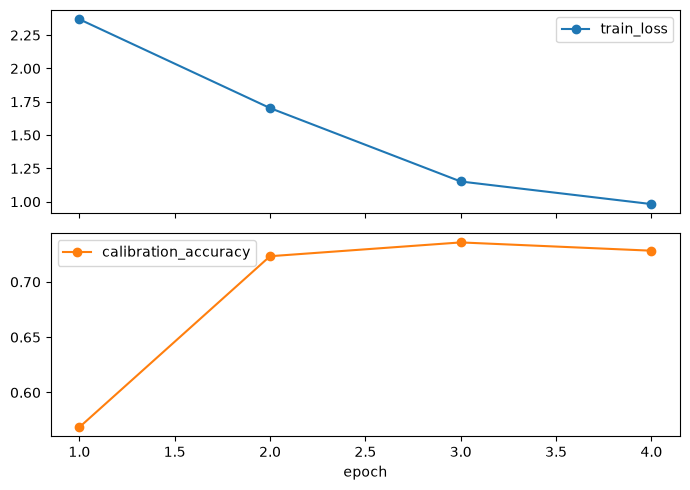

In [ ]:
pd.DataFrame(history).set_index("epoch").plot(subplots=True, figsize=(7, 5), marker="o")
plt.tight_layout(); plt.show()

---
## 8. Ablation: would TF-IDF + logistic regression have done?

The encoder costs ~90MB and eight minutes of training. A bag of words costs
neither, so the question deserves a measured answer rather than an assertion.

The 0.754 in §4 is **not** that answer. It is 5-fold CV over the whole corpus, so
variants of one scenario land in different folds — the contamination the grouped
split exists to prevent. Tuned honestly and reported once on the held-out test
split, the comparison looks different.

Two things are compared, and the second matters more:

1. **Accuracy** on the test split.
2. **Calibration** — the router reads a confidence and compares it to a threshold,
   so a model whose confidence cannot be trusted is unusable regardless of its
   accuracy. Logistic regression has no logits to temperature-scale.


In [ ]:
# Tuned on train, validated on calibration, reported ONCE on test -- the same
# discipline the encoder gets. Anything less would flatter the baseline.
from sklearn.model_selection import GridSearchCV, PredefinedSplit

tr, ca, te = (df[df.split == s] for s in ("train", "calibration", "test"))
fit_rows = pd.concat([tr, ca])
fold = np.r_[np.full(len(tr), -1), np.zeros(len(ca), dtype=int)]  # -1 = never validate

search = GridSearchCV(
    make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=3000, random_state=SEED)),
    {
        "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
        "tfidfvectorizer__min_df": [1, 2, 3],
        "tfidfvectorizer__sublinear_tf": [True, False],
        "logisticregression__C": [0.5, 1.0, 4.0, 16.0],
    },
    cv=PredefinedSplit(fold), scoring="accuracy", n_jobs=-1,
)
search.fit(fit_rows["text"], fit_rows["label"])
print(f"best parameters: {search.best_params_}")
print(f"calibration-split accuracy: {search.best_score_:.4f}")

baseline_test = (search.predict(te["text"]) == te["label"]).mean()
print(f"\nTUNED TF-IDF + LOGREG on test: {baseline_test:.4f}")

# Its confidence, unlike the encoder's, cannot be temperature-scaled: there are no
# logits behind predict_proba to divide. This is what that costs.
proba = search.predict_proba(te["text"])
confidence = proba.max(axis=1)
hit = (search.classes_[proba.argmax(axis=1)] == te["label"].to_numpy()).astype(float)

edges = np.linspace(0, 1, 16)
ece = sum(
    mask.mean() * abs(hit[mask].mean() - confidence[mask].mean())
    for lo, hi in zip(edges, edges[1:])
    if (mask := (confidence > lo) & (confidence <= hi)).sum()
)
print(f"expected calibration error   : {ece:.4f}")
print(f"mean confidence {confidence.mean():.3f} vs accuracy {hit.mean():.3f} "
      f"-> {'under' if confidence.mean() < hit.mean() else 'over'}-confident by "
      f"{abs(confidence.mean() - hit.mean()):.3f}")


### Reading the ablation

Run on the committed corpus, the bag of words reaches **0.571** on test against the
encoder's **0.612**, and its uncalibrated ECE is **0.263** — mean confidence 0.329
against 0.571 accuracy, badly under-confident with no temperature to correct it.

Tuning barely moved it: the grid picked near-default settings and preferred
unigrams, which is what a model with no more signal to extract looks like.

So the encoder is kept, and the reason is the second row rather than the first. A
four-point accuracy gap alone might not justify 90MB. A confidence the router can
actually threshold does, because that is the contribution — and it is the thing a
linear model over word counts structurally cannot provide.


---
## 9. Save the artefacts

Weights, the label order, and the training metadata. The label order matters as much
as the weights: a reordering would silently permute every prediction.

In [ ]:
OUT = ROOT / "models" / "classifier"
OUT.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), OUT / "model.pt")
# NOTE: state_dict stores tensors only -- no architecture. The runtime
# reads config.json from the BASE model directory and the weights from
# here, so there is one source of truth for the shape.
tokenizer.save_pretrained(OUT)
(OUT / "labels.json").write_text(json.dumps(LABELS, indent=2), encoding="utf-8")
(OUT / "training.json").write_text(json.dumps({
    "base_model": "sentence-transformers/all-MiniLM-L6-v2",
    "seed": SEED,
    "epochs": EPOCHS,
    "max_length": 256,
    "batch_size": 32,
    "learning_rate": 2e-5,
    "n_train": int((df.split == "train").sum()),
    "n_calibration": int((df.split == "calibration").sum()),
    "n_test": int((df.split == "test").sum()),
    "split_grouped_by": "scenario_id",
    "elapsed_seconds": round(elapsed, 1),
    "history": history,
    "note": ("calibration_accuracy is a convergence signal, not a result. "
             "Reported numbers come from eval/run_eval.py on the test split."),
}, indent=2), encoding="utf-8")

size_mb = sum(f.stat().st_size for f in OUT.rglob("*") if f.is_file()) / 1024**2
print(f"saved -> {OUT.relative_to(ROOT)}  ({size_mb:.1f}MB)")
if size_mb > 95:
    print("WARNING: approaching GitHub's 100MB limit; git-lfs would be needed.")

saved -> models\classifier  (87.4MB)


---
## 10. What happens next, and what deliberately does not happen here

Built here: a fine-tuned encoder and a dataset that has been audited for balance,
length artefacts, vocabulary leakage and cross-split duplication.

**Not here, on purpose:**

- **Temperature scaling** — fitted on the calibration split by
  `scripts/fit_calibration.py`.
- **Every reported number** — computed by `eval/run_eval.py` on the test split and
  written to `eval/results/`. The README cites those files, never a number
  remembered from a notebook run.

The separation is the guard against the code–writeup mismatch failure mode: a figure
in the writeup can always be traced to a committed file produced by a script, rather
than to a cell someone ran once.

---
## 11. What this run produced

Recorded so a number in the writeup can be traced to the run that made it.

| | |
|---|---|
| Corpus | 1,800 emails, 150/class, 0 generation failures |
| Generator | `gpt-4o`, ~50 min, seed 42 |
| Splits | 879 train / 401 calibration / 520 test, grouped by scenario |
| Model | MiniLM-L6, 22.7M params, 87.4MB, 4 epochs, ~8 min on CPU |
| Convergence | loss 2.37 → 0.98; calibration accuracy 0.57 → 0.74 |

**Epoch 4 dipped** (0.7357 → 0.7282). On 879 training examples that is the onset of
overfitting, and it is the reason the epoch count is not raised without measuring:
a longer run would lower training loss while learning the corpus rather than the
task.

**None of the above is a result.** Calibration accuracy is a convergence signal
taken from the split that also fits the temperature. Every reported number comes
from `eval/run_eval.py` on the held-out test split and is written to
`eval/results/`, so the README can cite a committed file rather than a remembered
figure from a notebook run.